In [33]:
import tensorflow as tf
import numpy as np
import pandas as pd

from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.model_selection import train_test_split

In [34]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

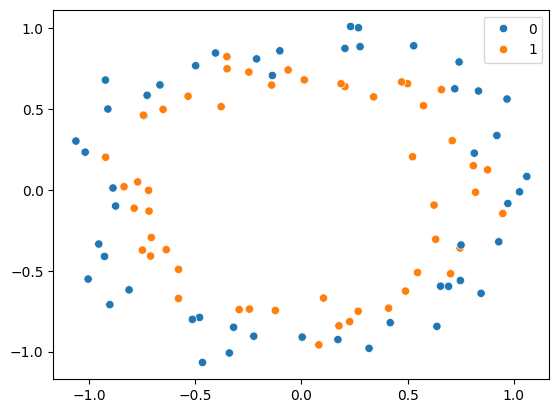

In [35]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
plt.show()

In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=2)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create an empty Sequential model.
# Sequential means layers are added one after another.
model = Sequential()

# -------------------- First Hidden Layer --------------------
model.add(
    Dense(
        256,                 # Number of neurons in this layer.
        input_dim=2,         # Input has 2 features (X1 and X2 from make_circles).
        activation='relu'    # Activation function: ReLU = max(0, x).
    )
)

# -------------------- Output Layer --------------------
model.add(
    Dense(
        1,                   # One neuron because this is binary classification.
        activation='sigmoid' # Sigmoid outputs a probability between 0 and 1.
    )
)

# -------------------- Compile the Model --------------------
model.compile(

    # Loss function used to measure prediction error.
    # Binary Crossentropy is used for binary classification.
    loss='binary_crossentropy',

    # Optimizer updates the weights during training.
    # Adam is the most commonly used optimizer.
    optimizer='adam',

    # Metrics to display while training.
    # Accuracy = percentage of correctly classified samples.
    metrics=['accuracy']
)

e:\Deep_Learning\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [39]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=1000,verbose=0)

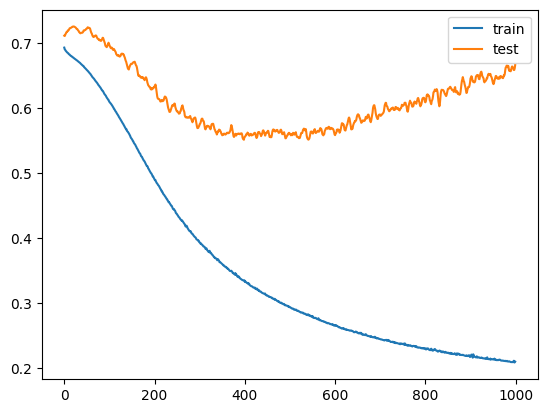

In [40]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


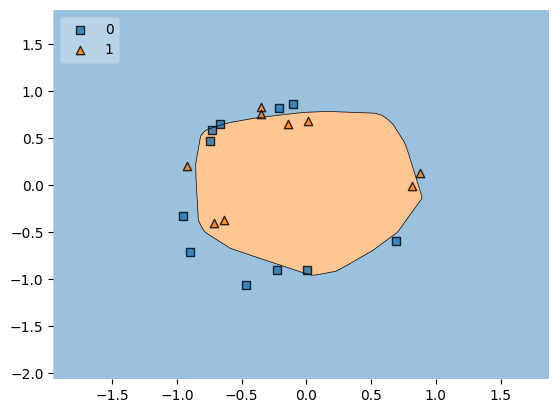

In [41]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)
plt.show()

In [42]:
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [43]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Create an EarlyStopping callback
callback = EarlyStopping(

    # Metric to monitor during training.
    # Common options: "val_loss", "loss", "val_accuracy", "accuracy"
    # Here, training monitors the validation loss.
    monitor="val_loss",

    # Minimum improvement required to consider the metric as improved.
    # If the validation loss decreases by less than 0.00001,
    # it is considered "no improvement".
    min_delta=0.00001,

    # Number of consecutive epochs with no improvement
    # before stopping training.
    # Here, if val_loss doesn't improve for 20 epochs,
    # training will stop.
    patience=20,

    # Controls the amount of information printed.
    # verbose=0 -> No message
    # verbose=1 -> Prints a message when training stops
    verbose=1,

    # Determines whether the monitored metric should
    # increase or decrease.
    # "auto" automatically chooses:
    #   val_loss -> minimize
    #   val_accuracy -> maximize
    # Other options:
    #   "min" -> lower is better
    #   "max" -> higher is better
    mode="auto",

    # Baseline value that the monitored metric must beat.
    # If None, no baseline is used.
    baseline=None,

    # If True, restores the model weights from the epoch
    # with the best monitored metric after training stops.
    # If False, keeps the weights from the last epoch.
    restore_best_weights=False
)

In [50]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=1000,callbacks=callback)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5250 - loss: 0.6943 - val_accuracy: 0.4000 - val_loss: 0.7028
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5125 - loss: 0.6935 - val_accuracy: 0.4000 - val_loss: 0.7041
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5500 - loss: 0.6919 - val_accuracy: 0.3500 - val_loss: 0.7055
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5375 - loss: 0.6910 - val_accuracy: 0.3000 - val_loss: 0.7073
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5625 - loss: 0.6903 - val_accuracy: 0.3000 - val_loss: 0.7086
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5625 - loss: 0.6898 - val_accuracy: 0.4000 - val_loss: 0.7083
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5625 - loss: 0.6883 - val_accuracy: 0.4000 - val_loss: 0.7086
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5375 - loss: 0.6878 - val_accuracy: 0.4500 - 

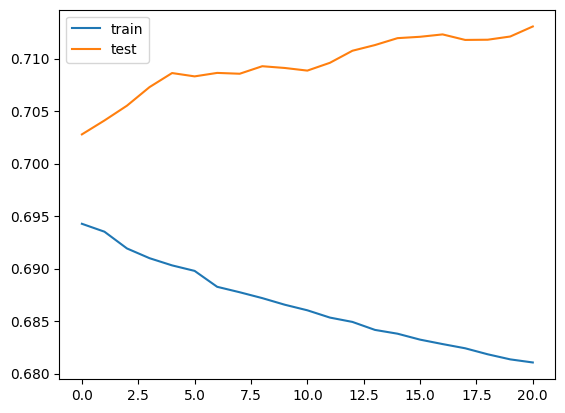

In [51]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

In [ ]:
# # early Stopping is a technique used in deep learning to stop training automatically when the model stops improving on the validation data. It helps prevent overfitting and saves training time.
# Epoch 1   → Learning 
# Epoch 20  → Better 
# Epoch 40  → Best Model 
# Epoch 50  → Starts Overfitting 
# Epoch 80  → More Overfitting 
# Epoch 100 → Worse Performance 

# Epoch 1   → Learning
# Epoch 20  → Better
# Epoch 40  → Best Model 
# Epoch 41  → No improvement
# Epoch 42  → No improvement
# ...
# Epoch 60  → Stop Training 